In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print(" All imports done!")

TensorFlow version: 2.21.0
 All imports done!


In [3]:
df = pd.read_csv('../data/PS2_Dataset.csv')

def assign_role(row):
    career   = row['interested career area '].strip()
    subject  = row['Interested subjects'].strip()
    cert     = row['certifications'].strip()
    workshop = row['workshops'].strip()
    mgmt     = row['Management or Technical'].strip()
    company  = row['Type of company want to settle in?'].strip()
    coding   = row['coding skills rating']

    if career == 'security' or subject == 'hacking':
        if workshop == 'hacking' or cert == 'information security':
            return 'Systems Security Administrator'
        return 'Network Security Engineer'
    if career == 'testing' or workshop == 'testing':
        return 'Software Quality Assurance (QA) / Testing'
    if career == 'cloud computing' or subject == 'cloud computing':
        if company == 'Web Services' or workshop == 'web technologies':
            return 'Web Developer'
        return 'Network Security Engineer'
    if career == 'Business process analyst' or mgmt == 'Management':
        if subject == 'data engineering' or cert == 'hadoop':
            return 'Database Developer'
        if company in ['SAaS services', 'Sales and Marketing']:
            return 'CRM Technical Developer'
        return 'Technical Support'
    if career == 'developer':
        if cert == 'app development' or workshop == 'game development':
            return 'Mobile Applications Developer'
        if cert == 'machine learning' or subject == 'data engineering':
            return 'Applications Developer'        
        if workshop == 'web technologies' or cert == 'full stack':
            return 'Web Developer'
        if coding >= 7:
            return 'Software Engineer'
        return 'Software Developer'
    if career == 'system developer':
        if subject == 'networks' or workshop == 'database security':
            return 'Database Developer'
        if subject == 'IOT':
            return 'CRM Technical Developer'
        if subject == 'Computer Architecture' or workshop == 'system designing':
            return 'Systems Security Administrator'
        if coding >= 7:
            return 'Software Engineer'
        return 'Software Developer'
    if subject == 'programming' and coding >= 7:
        return 'Software Engineer'
    return 'Technical Support'

df['New Job Role'] = df.apply(assign_role, axis=1)
print("Data loaded and target rebuilt!")
print("Shape:", df.shape)

Data loaded and target rebuilt!
Shape: (6901, 21)


In [4]:
df_enc = df.drop('Suggested Job Role', axis=1).copy()
encoders = {}

ordinal = {
    'reading and writing skills': {'poor': 0, 'medium': 1, 'excellent': 2},
    'memory capability score':    {'poor': 0, 'medium': 1, 'excellent': 2},
}
for col, mapping in ordinal.items():
    df_enc[col] = df_enc[col].map(mapping)
    encoders[col] = mapping

str_cols = [c for c in df_enc.columns
            if str(df_enc[c].dtype) == 'str'
            and c not in ordinal
            and c != 'New Job Role']
for col in str_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str).values)
    encoders[col] = le

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(df_enc['New Job Role'].astype(str).values)
class_names = le_target.classes_
num_classes = len(class_names)

print("Encoding done!")
print(f"Number of classes: {num_classes}")
print("Classes:", class_names)

Encoding done!
Number of classes: 11
Classes: ['Applications Developer' 'CRM Technical Developer' 'Database Developer'
 'Mobile Applications Developer' 'Network Security Engineer'
 'Software Developer' 'Software Engineer'
 'Software Quality Assurance (QA) / Testing'
 'Systems Security Administrator' 'Technical Support' 'Web Developer']


In [5]:
X = df_enc.drop('New Job Role', axis=1)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# For deep learning — normalize features to 0-1 range
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode target for neural network
# Example: class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
y_onehot = to_categorical(y_encoded, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Also keep integer labels for sklearn metrics later
_, _, y_train_int, y_test_int = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Data ready for neural network!")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}  ← one-hot encoded")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes:  {num_classes}")

Data ready for neural network!
X_train: (5520, 19)
y_train: (5520, 11)  ← one-hot encoded
Number of features: 19
Number of classes:  11


In [6]:
model = keras.Sequential([

    # Input layer
    layers.Input(shape=(X_train.shape[1],)),

    # Hidden layer 1
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden layer 2
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden layer 3
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Output layer — one neuron per career class
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,027 (54.79 KB)

 Trainable params: 13,643 (53.29 KB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")
print("Optimizer: Adam")
print("Loss: Categorical Crossentropy")

Model compiled!
Optimizer: Adam
Loss: Categorical Crossentropy


In [8]:
# Stop training early if no improvement
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("Training complete!")

Epoch 1/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2360 - loss: 2.4045 - val_accuracy: 0.4031 - val_loss: 1.9220
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3673 - loss: 1.9097 - val_accuracy: 0.4402 - val_loss: 1.7476
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4119 - loss: 1.8041 - val_accuracy: 0.4511 - val_loss: 1.6598
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4296 - loss: 1.7246 - val_accuracy: 0.4692 - val_loss: 1.5888
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4352 - loss: 1.6735 - val_accuracy: 0.4692 - val_loss: 1.5471
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4522 - loss: 1.6247 - val_accuracy: 0.4783 - val_loss: 1.5072
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4574 - loss: 1.5765 - val_accuracy: 0.4764 - val_loss: 1.4788
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4746 - loss: 1.5308 - val

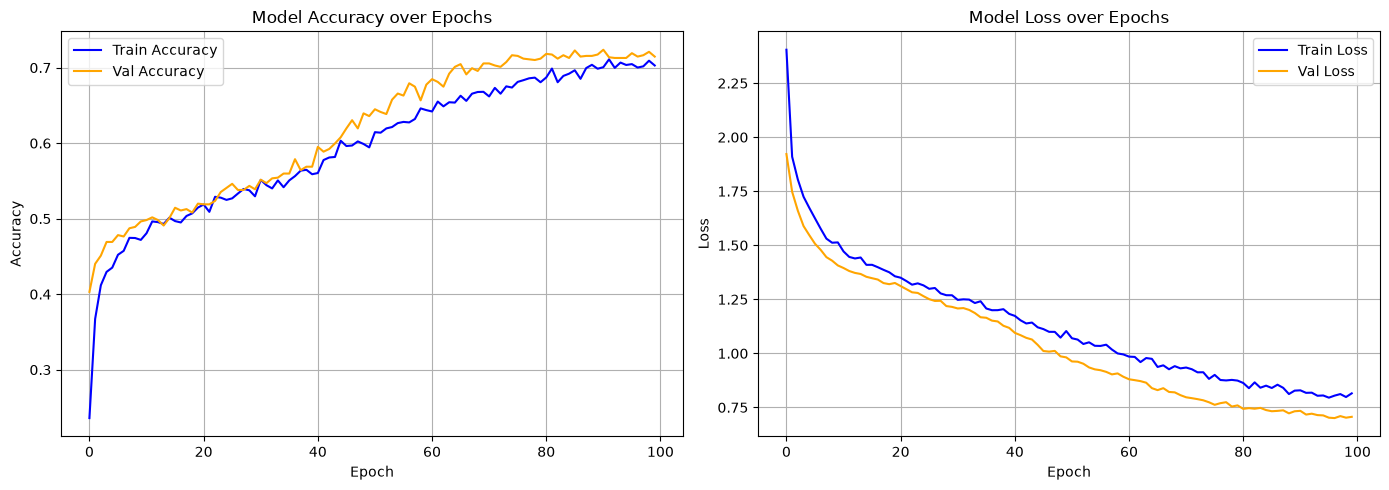

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Neural Network Test Accuracy: {test_acc*100:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred_int   = np.argmax(y_pred_probs, axis=1)

print("\n── Detailed Report ──")
print(classification_report(y_test_int, y_pred_int, target_names=class_names))

 Neural Network Test Accuracy: 74.29%
   Test Loss: 0.6748
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

── Detailed Report ──
                                           precision    recall  f1-score   support

                   Applications Developer       0.38      0.21      0.27        14
                  CRM Technical Developer       0.27      0.07      0.12        54
                       Database Developer       0.26      0.07      0.11        89
            Mobile Applications Developer       0.41      0.50      0.45        18
                Network Security Engineer       0.75      0.89      0.81       453
                       Software Developer       0.41      0.62      0.49        47
                        Software Engineer       0.50      0.41      0.45        22
Software Quality Assurance (QA) / Testing       0.89      0.98      0.94       304
           Systems Security Administrator       0.71      0.11      0.19        94
                        Technical Support       

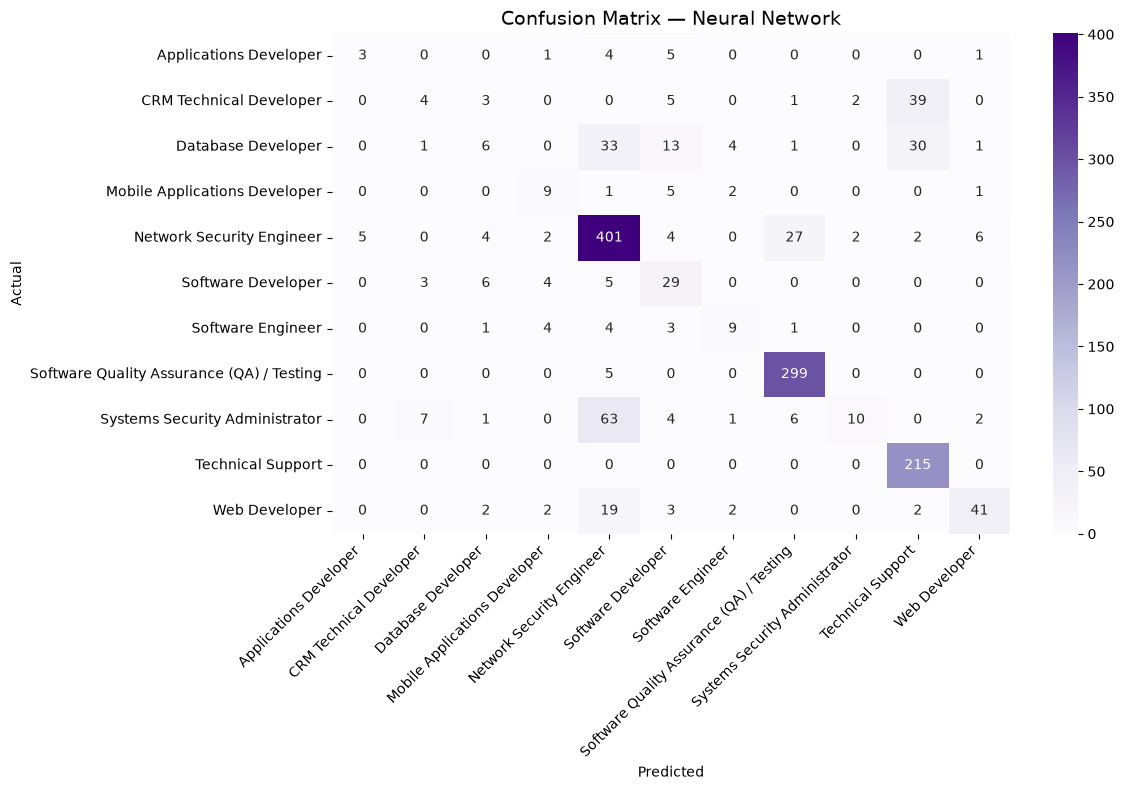

In [11]:
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Neural Network', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

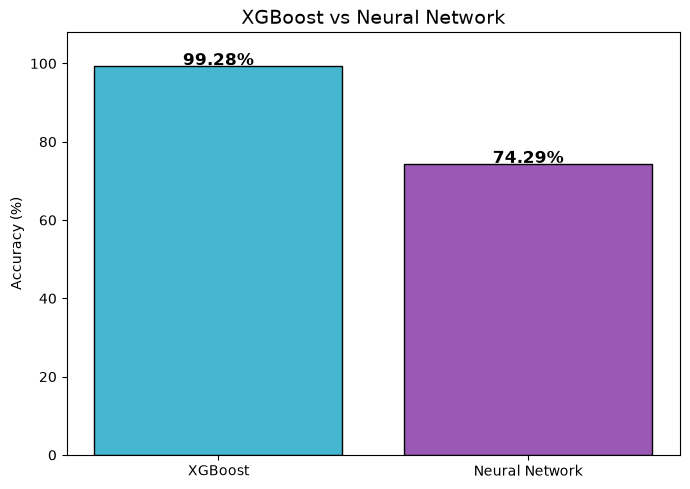


 Winner: XGBoost


In [12]:
# Load XGBoost accuracy from previous notebook
xgb_accuracy = 0.9928  # from notebook 03

dl_accuracy = test_acc

models_compare = {
    'XGBoost':        xgb_accuracy * 100,
    'Neural Network': dl_accuracy  * 100,
}

plt.figure(figsize=(7, 5))
bars = plt.bar(models_compare.keys(),
               models_compare.values(),
               color=['#45B7D1', '#9B59B6'],
               edgecolor='black')

for bar, val in zip(bars, models_compare.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.2f}%',
             ha='center', fontweight='bold', fontsize=12)

plt.title('XGBoost vs Neural Network', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 108)
plt.tight_layout()
plt.show()

winner = 'XGBoost' if xgb_accuracy > dl_accuracy else 'Neural Network'
print(f"\n Winner: {winner}")

In [13]:
os.makedirs('../models', exist_ok=True)

# Save in keras format
model.save('../models/dl_model.keras')

# Save scaler — needed in Streamlit app
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Neural network saved as dl_model.keras")
print("Scaler saved as scaler.pkl")

Neural network saved as dl_model.keras
Scaler saved as scaler.pkl
